In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Imposto lo stile dei grafici
sns.set_theme(style="whitegrid")
os.makedirs('output/grafici', exist_ok=True)

# 1. Carico cleaned_retail.csv nel notebook
df = pd.read_csv('output/dati_puliti/cleaned_retail.csv')

# 2. Calcolo il fatturato totale raggruppato per Country
geo_revenue = df.groupby('Country')['TotalPrice'].sum().reset_index()
geo_revenue = geo_revenue.sort_values(by='TotalPrice', ascending=False)

print("--- TOP 5 PAESI PER FATTURATO ---")
print(geo_revenue.head(5))

--- TOP 5 PAESI PER FATTURATO ---
           Country   TotalPrice
40  United Kingdom  9160457.807
11            EIRE   275030.110
15         Germany   266907.551
14          France   206820.160
36     Switzerland    53805.120


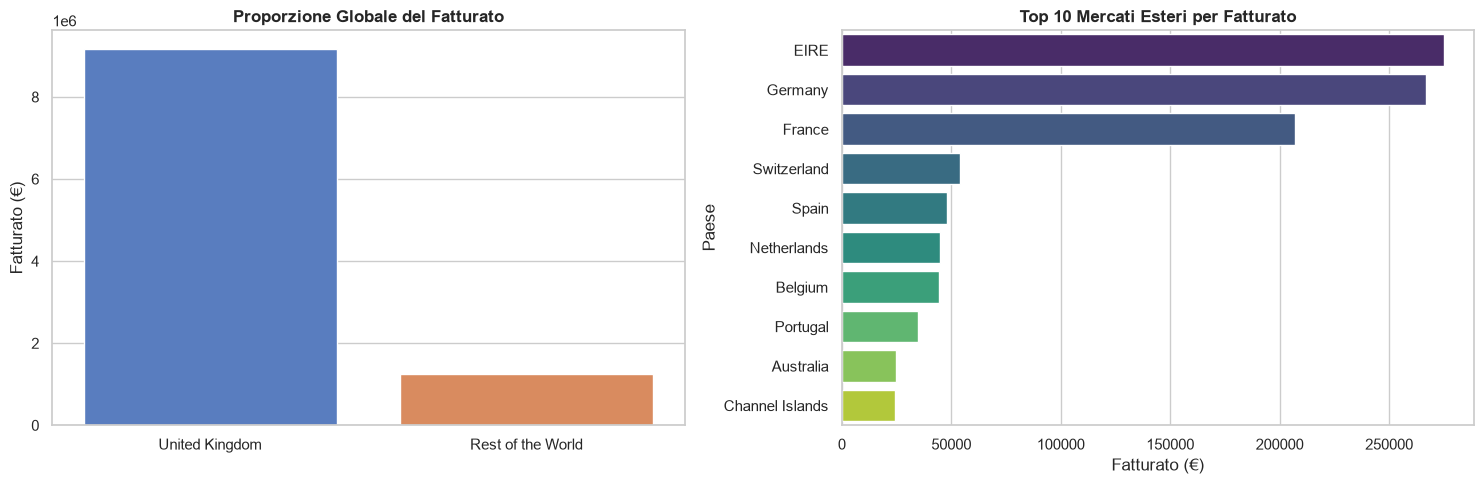

In [10]:
# Creo un dataframe dove unisco tutti i paesi No-UK sotto la voce 'Rest of the World'
revenue_uk = geo_revenue[geo_revenue['Country'] == 'United Kingdom']['TotalPrice'].values[0]
revenue_row = geo_revenue[geo_revenue['Country'] != 'United Kingdom']['TotalPrice'].sum()

global_comparison = pd.DataFrame({
    'Market': ['United Kingdom', 'Rest of the World'],
    'Fatturato': [revenue_uk, revenue_row]
})

# Preparo i dati per il secondo grafico (Top 10 esteri)
no_uk_data = geo_revenue[geo_revenue['Country'] != 'United Kingdom'].head(10)

# Creio un pannello con due grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Proporzione Globale (UK vs Mondo)
sns.barplot(data=global_comparison, x='Market', y='Fatturato', hue='Market', palette='muted', ax=axes[0], legend=False)
axes[0].set_title('Proporzione Globale del Fatturato', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fatturato (€)')
axes[0].set_xlabel('')

# Grafico 2: Dettaglio Mercati Esteri (Senza l'effetto schiacciamento dell'UK)
sns.barplot(data=no_uk_data, x='TotalPrice', y='Country', hue='Country', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Top 10 Mercati Esteri per Fatturato', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fatturato (€)')
axes[1].set_ylabel('Paese')

plt.tight_layout()

# Salvo il pannello unico completo
plt.savefig('output/grafici/analisi_geografica_completa.png', dpi=300)
plt.show()